In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import math, copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
housing = fetch_california_housing()

In [3]:
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df["PRICE"] = housing.target
x = housing_df.drop("PRICE" , axis=1).to_numpy()
y = housing_df['PRICE'].to_numpy()
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)


In [4]:
print("Dataset shape:", x_train.shape)
print("\nFeatures:")
print(housing.feature_names)
print("\nTarget:", housing.target_names)

# Basic statistics
housing_df.describe()

# Check for missing values
housing_df.isnull().sum()

Dataset shape: (16512, 8)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: ['MedHouseVal']


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [5]:
def feature_scaling(x_train , return_params=False):
    """
    Perform feature scaling using standardization (Z-score normalization)
    
    Parameters:
    x_train (numpy.ndarray): Input feature matrix
    
    Returns:
    numpy.ndarray: Scaled feature matrix
    """
    # Create a copy to avoid modifying the original array
    scaled_x_train = x_train.copy().astype(float)
    params = {'mean': [], 'std': []}
    # Scale each column (feature) separately
    for j in range(x_train.shape[1]):
        # Extract the current feature column
        feature = x_train[:, j]
        # Calculate mean and standard deviation
        mean = np.mean(feature)
        std = np.std(feature)

        params['mean'].append(mean)
        params['std'].append(std)
        # Apply z-score normalization
        scaled_x_train[:, j] = (feature - mean) / std
    
    if return_params:
        return scaled_x_train, params
    else:
        return scaled_x_train

In [8]:
print(x_train.shape , x_train.shape[1])

(16512, 8) 8


In [9]:
def compute_model_prediction(x , w , b):
    model_output = np.dot(x,w) + b
    return model_output

In [10]:
def compute_cost(x_train, w ,b , y_train ):
    cost = 0
    m = x_train.shape[0]
    for i in range(m):
        model_output = compute_model_prediction(x_train[i], w,b)
        cost = cost + (y_train[i] - model_output)**2
    total_cost = cost / (2*m)
    return total_cost

In [11]:
def compute_gradient_descent(x_train , y_train , w , b):
    m , n = x_train.shape
    dw = np.zeros((n,)) 
    db = 0
    for i in range(m):
        model_prediction = compute_model_prediction(x_train[i] , w , b)
        diff = model_prediction - y_train[i]
        for j in range(n):
            dw[j] = dw[j] + diff * x_train[i][j]
        db = db + diff
    dw_dj = dw / m
    db_dj = db / m 
    return dw_dj , db_dj

In [12]:
def gradient_descent(x_train , y_train , w , b , alpha_in , iteration):
    m , n = x_train.shape
 
    alpha = alpha_in
    cost = compute_cost(x_train , w ,b , y_train)
    costs = []
    iterations = []
    w1_range = []
    w2_range = []
    w3_range = []
    for i in range(iteration):
 
        dw_dj , db_dj = compute_gradient_descent(x_train , y_train , w , b)
        w = w - alpha * dw_dj
        b = b - alpha * db_dj
        cost = compute_cost(x_train , w ,b , y_train)
        costs.append(cost)
        iterations.append(i)
        #print(w , w[0])
        #w1_range.append(w[0])
        #w2_range.append(w[1])
        #print(w , " " , b , " " , cost)
        
    return w , b , w1_range , w2_range , costs , iterations

In [13]:
def plot_cost_vs_iteration(iterations, costs):
    """
    Plot a graph of cost versus iteration.
    
    Parameters:
    iterations (list or numpy array): Number of iterations
    costs (list or numpy array): Corresponding cost values
    """
    plt.figure(figsize=(10, 10))
    plt.plot(iterations, costs, marker='o')
    plt.title('Cost vs Iteration', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [14]:
def evaluate_model(X, y, w, b):
    """
    Evaluate the model on a dataset.
    """
    # Make predictions
    y_pred = np.dot(X, w) + b
    
    # Calculate Mean Squared Error
    mse = np.mean((y - y_pred) ** 2)
    
    # Calculate Root Mean Squared Error
    rmse = np.sqrt(mse)
    
    # Calculate R-squared
    y_mean = np.mean(y)
    ss_total = np.sum((y - y_mean) ** 2)
    ss_residual = np.sum((y - y_pred) ** 2)
    r2 = 1 - (ss_residual / ss_total)
    
    return mse, rmse, r2

In [15]:
def plot_predictions_vs_actual(y_actual, y_pred, title):
    """
    Plot predicted values against actual values.
    """
    plt.figure(figsize=(10, 6))
    plt.scatter(y_actual, y_pred, alpha=0.5)
    
    # Add a perfect prediction line
    min_val = min(np.min(y_actual), np.min(y_pred))
    max_val = max(np.max(y_actual), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_feature_importance(feature_names, weights):
    """
    Plot the importance of each feature based on absolute weight values.
    """
    # Create a DataFrame with feature names and their absolute weights
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Absolute Weight': np.abs(weights),
        'Weight': weights
    }).sort_values('Absolute Weight', ascending=False)
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(importance_df['Feature'], importance_df['Absolute Weight'])
    
    # Color bars based on positive/negative weight
    for i, bar in enumerate(bars):
        if importance_df.iloc[i]['Weight'] < 0:
            bar.set_color('red')
        else:
            bar.set_color('blue')
    
    plt.xlabel('Absolute Weight Value')
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.show()

Initial weights and bias: [0. 0. 0. 0. 0. 0. 0. 0.] 0
Final weights and bias: [ 0.85544466  0.12279978 -0.29625148  0.34072001 -0.00222776 -0.04087967
 -0.89415857 -0.86719242] 2.0719469373788555

Training Set Performance:
MSE: 0.5179
RMSE: 0.7197
R²: 0.6126

Validation Set Performance:
MSE: 0.5560
RMSE: 0.7457
R²: 0.5757


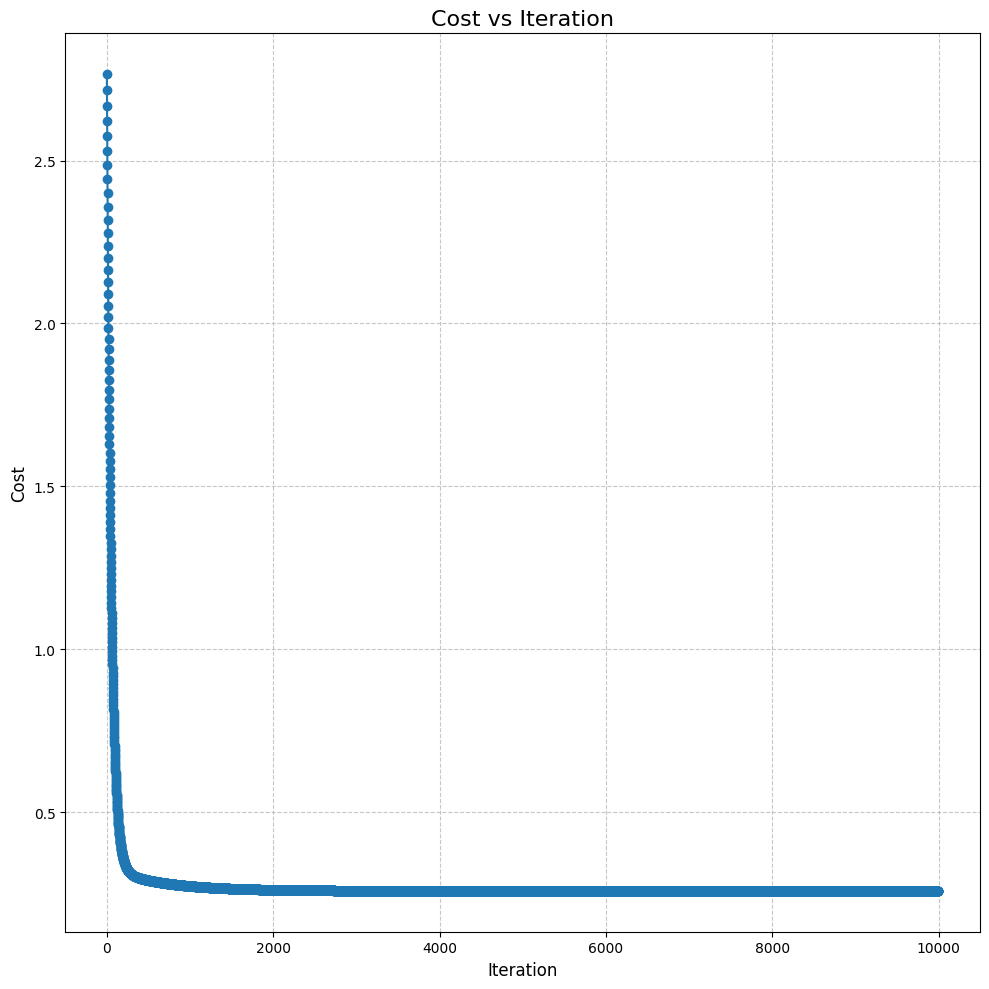

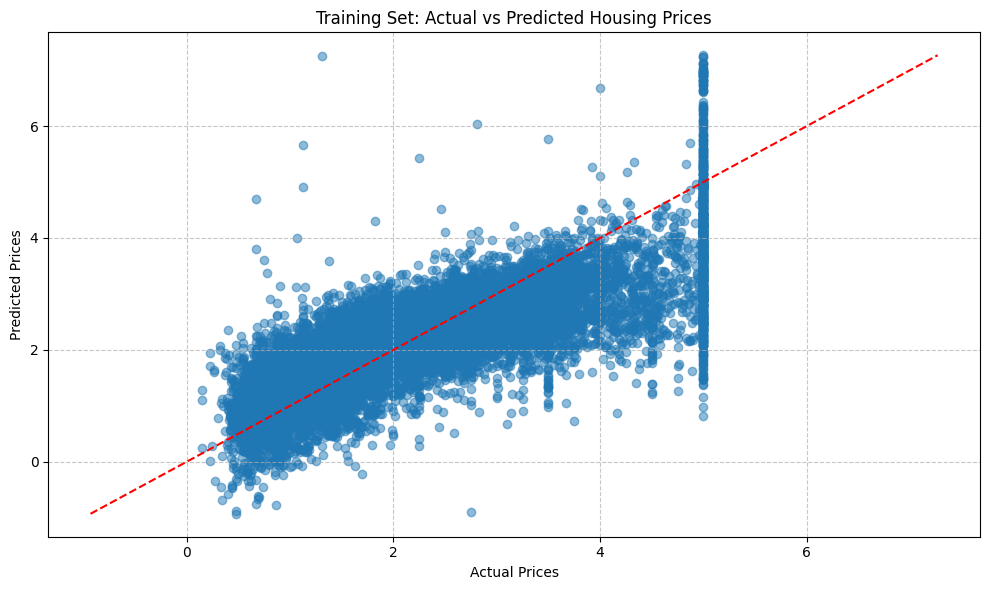

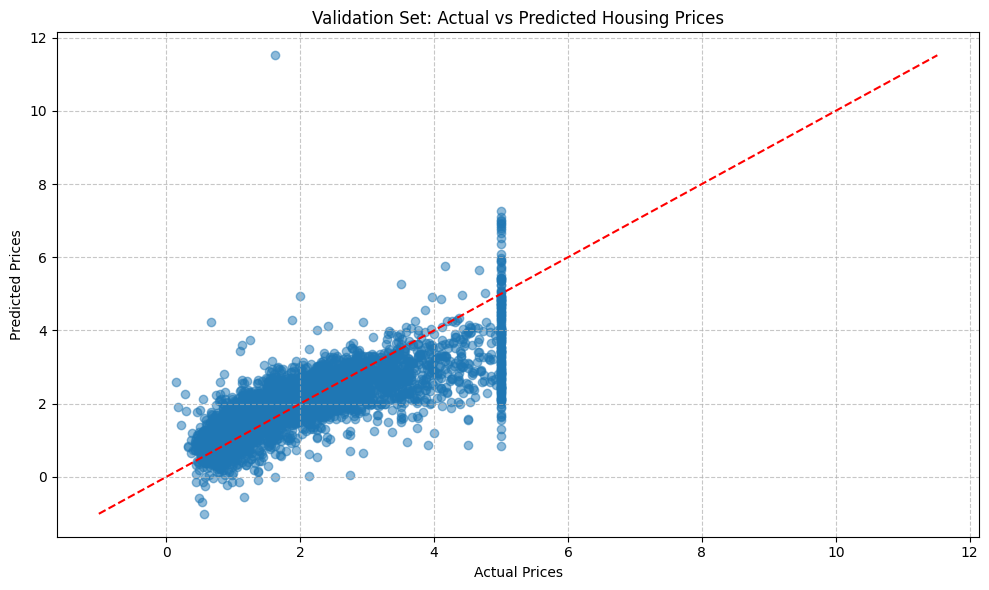

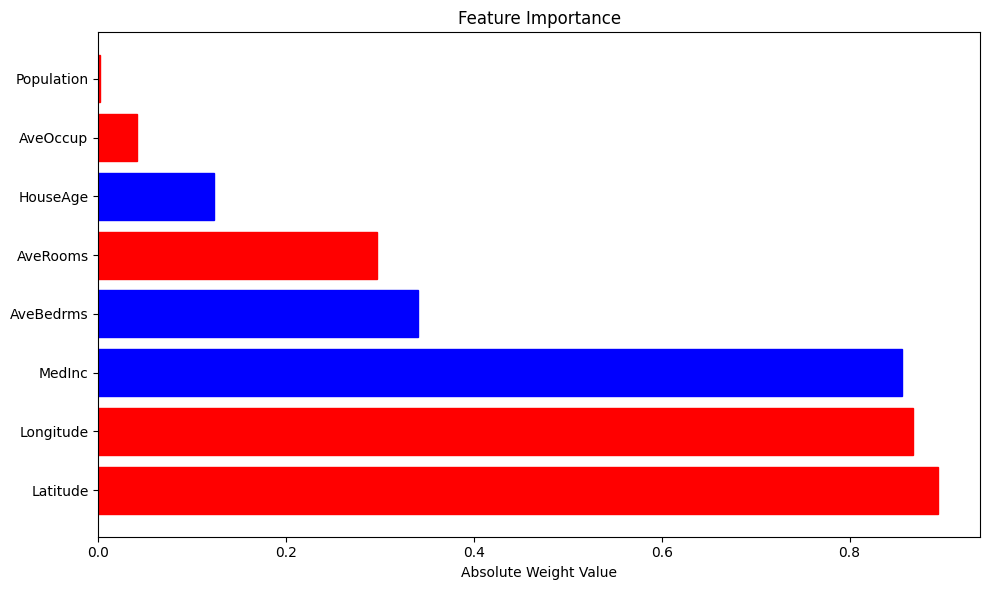

In [19]:
# Scale training data and get scaling parameters
X_train_scaled, scaling_params = feature_scaling(x_train, return_params=True)

# Apply the same scaling to validation data
X_val_scaled = x_val.copy().astype(float)
for j in range(x_val.shape[1]):
    X_val_scaled[:, j] = (x_val[:, j] - scaling_params['mean'][j]) / scaling_params['std'][j]

# Initialize parameters
m, n = X_train_scaled.shape
w = np.zeros(n)
b = 0
print("Initial weights and bias:", w, b)

# Train model
w, b, w1_range, w2_range, costs, iterations = gradient_descent(X_train_scaled, y_train, w, b, 0.01, 10000)
print("Final weights and bias:", w, b)

# Evaluate on training set
train_mse, train_rmse, train_r2 = evaluate_model(X_train_scaled, y_train, w, b)
print("\nTraining Set Performance:")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R²: {train_r2:.4f}")

# Evaluate on validation set
val_mse, val_rmse, val_r2 = evaluate_model(X_val_scaled, y_val, w, b)
print("\nValidation Set Performance:")
print(f"MSE: {val_mse:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²: {val_r2:.4f}")

# Make predictions
y_train_pred = np.dot(X_train_scaled, w) + b
y_val_pred = np.dot(X_val_scaled, w) + b

# Plot predictions
plot_cost_vs_iteration(iterations, costs)
plot_predictions_vs_actual(y_train, y_train_pred, 'Training Set: Actual vs Predicted Housing Prices')
plot_predictions_vs_actual(y_val, y_val_pred, 'Validation Set: Actual vs Predicted Housing Prices')

# Plot feature importance
plot_feature_importance(housing.feature_names, w)